## ML-Based Patient Selection Framework

This project treats machine-learning predictions as patient-level scores that can support both **enrichment** and **stratification**.

In an **enrichment** workflow, a score is used with a fixed threshold to select a subgroup for focused enrollment, validation, or follow-up.

In a **stratification** workflow, the same type of score is divided into multiple intervals to create ordered patient strata, such as low, medium, and high likelihood groups.

Enrichment and stratification can use the same underlying patient-level score; the difference is whether the score is used to select one subgroup or to divide the population into multiple ordered groups.

The clinical interpretation of the score depends on what the score is designed to represent: **diagnostic likelihood**, **prognostic outcome likelihood**, or **treatment benefit**.

| Patient selection framework | Core question | Score used | Enrichment use | Stratification use | Status |
|---|---|---|---|---|---|
| **Diagnostic** | **Who likely has the disease or diagnostic target?** | **`P(disease given baseline features)`** | **Select patients above a diagnostic-likelihood threshold** | **Group patients into low, medium, and high diagnostic-likelihood strata** | **Primary focus** |
| Prognostic | Who likely experiences the future outcome of interest? | `P(future outcome given baseline features)` | Select patients above an outcome-probability threshold | Group patients into low, medium, and high outcome-likelihood strata | Related workflow |
| Treatment-benefit / treatment-effect | Who likely benefits more from treatment than control or no treatment? | Estimated treatment benefit | Select patients above a treatment-benefit threshold | Group patients into low, medium, and high treatment-benefit strata | Future work |

In this notebook, the primary focus is **diagnostic enrichment**. The patient-level score is interpreted as the predicted probability of the diagnostic positive class, and a fixed probability threshold is applied to select a diagnostic-enriched subgroup.

This workflow asks whether baseline data can identify patients who are more likely to have the diagnostic target. It does not estimate future treatment response or treatment-specific benefit.

#### Import packages

In [13]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs

import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut
import ai_framework.validation as vld

import pandas as pd
import numpy as np


##### Load final results and selected features per model

In [14]:
# Load output
all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
final_features    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_features', compress=True)
bundle            = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


## From Nested Cross-Validation Outputs to Patient-Level Probabilities

The enrichment and stratification analyses are performed at the **patient level**, but the model-development workflow can generate multiple predictions per patient.

During repeated cross-validation, a patient may receive multiple out-of-sample predicted probabilities across observation windows, outer folds, repeated trials, model runs, and calibration variants.

This step converts those repeated predictions into a clean **patient-level probability table** for downstream enrichment and stratification.


### Workflow Overview

The workflow has two main stages:

1. **Build a long-form prediction table**  
   The nested cross-validation outputs are unpacked into a tidy table where each row represents one prediction from a specific model, calibration variant, split, trial, outer fold, and patient.

2. **Pool predictions into a patient-level summary**  
   For each patient, repeated out-of-sample predictions are pooled into a single patient-level summary.

The main patient-level score used downstream is **`p_mean`**, which represents the pooled predicted probability for each patient.

The summary also includes **`p_total_std`**, which captures how much a patient’s predicted probabilities vary across repeated predictions and can be used to visualize prediction stability or uncertainty.

---

### Interpretation

In a **diagnostic enrichment or stratification workflow**, `p_mean` is interpreted as the predicted probability of the diagnostic positive class.

In a **prognostic enrichment or stratification workflow**, `p_mean` is interpreted as the predicted probability of the future outcome of interest, such as treatment response.


### Summary

This step transforms repeated model-development outputs into the patient-level probability table required for downstream analysis:

**cross-validation prediction outputs → long-form prediction table → pooled patient-level probability summary → enrichment / stratification analysis**

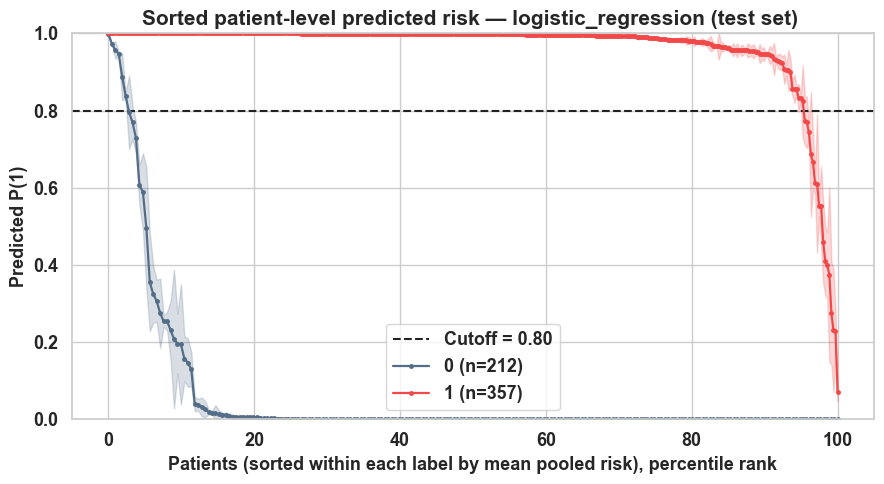

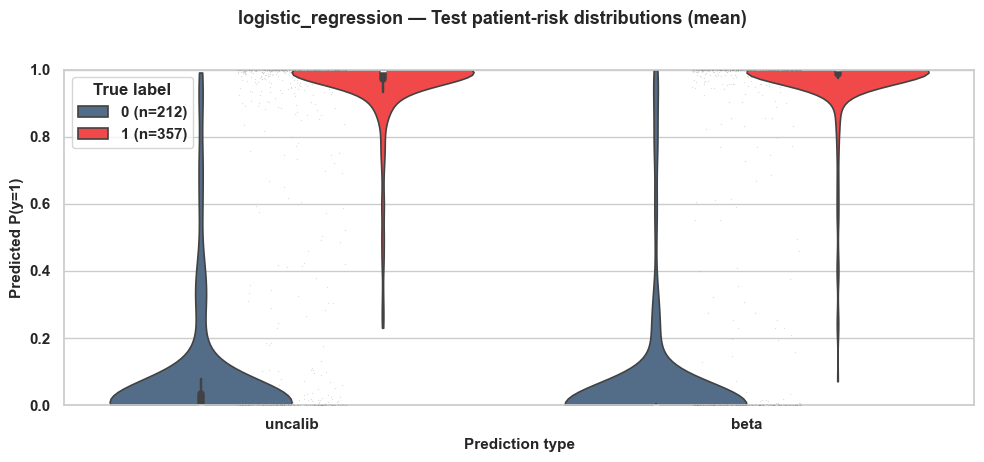

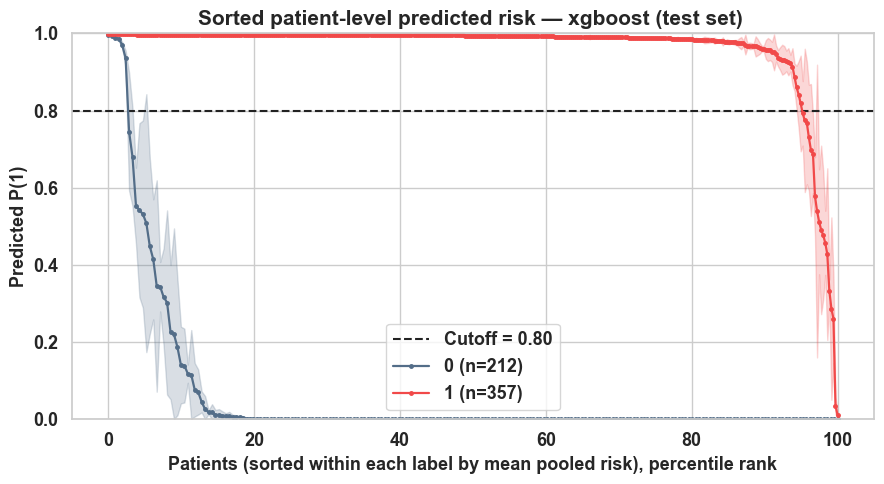

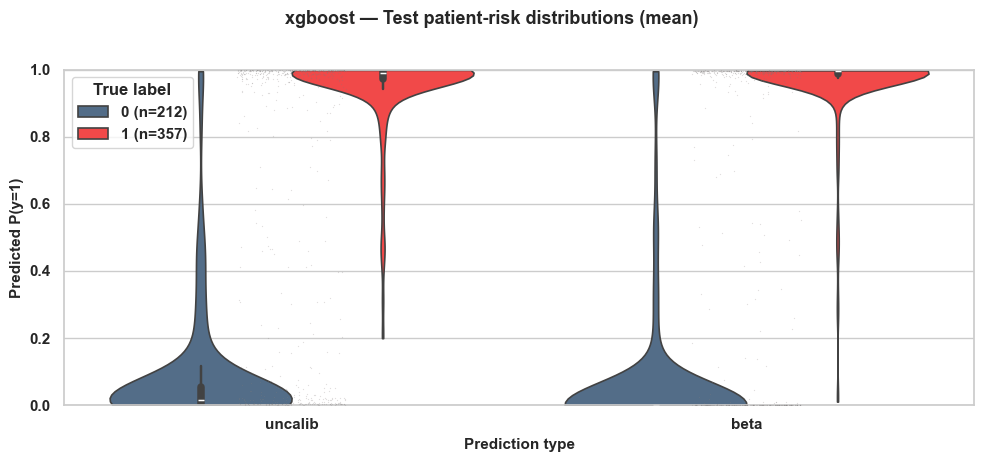

In [15]:

neg_plot_color = "#536D88"
pos_plot_color = "#F14949"

# Fixed enrichment threshold:
# patients with predicted probability >= 0.80 are treated as selected
threshold = 0.80

df_long = mtci.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    groups_all = None,
    group_id_to_key=None,
    include_uncalibrated=True,
    include_test=True,
    include_train_oof=False,   # keep off for now
    unit_col="idx"
)


df_pat = mtci.pooled_patient_risk_summary(
    df_long,
    grouping="all_trials", # per_trial_fold
    unit_col="idx",
    agg="mean",
    lower_q=0.0,
    upper_q=1.0,
    include_test=True,
    include_train_oof=False,
    truncate_decimals=4,
)



out_pat = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="logistic_regression",
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],   
    split="test",
    group_label=None,            
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)




_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="logistic_regression",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)": neg_plot_color, "1 (pos)": pos_plot_color},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)






out_pat_xgb = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="xgboost",
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],   
    split="test",
    group_label=None,               
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)


_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="xgboost",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)": neg_plot_color, "1 (pos)": pos_plot_color},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)



## Threshold-based enrichment analysis


This section applies the fixed enrichment threshold to patient-level predictions in order to define a selected subgroup.

The enrichment analysis is summarized at three levels:

1. **Pocket summary**  
   Describes the selected subgroup itself, including the number selected, PPV, contamination, and enrichment factor.

2. **Operating summary**  
   Describes what the threshold does in the full screened population, including sensitivity, specificity, NPV, percent selected, and screening burden.

3. **Planning summary**  
   Uses the observed PPV and percent selected to estimate how many selected patients are needed to validate the enrichment rule with a desired level of precision, and how many total patients would need to be screened to obtain them.


### Why this is useful (use case for clinical data)
Clinical data classification performance is often modest at the population level. This function supports the hypothesis that **data separability is heterogeneous**: there may exist subsets of individuals for whom clinical data provides stronger, more consistent discriminative signal. Identifying and quantifying these pockets enables **focused follow-up analyses** and motivates **enrichment strategies** for future studies (e.g., prioritizing Eseparable individuals for deeper phenotyping or prospective validation).


In [16]:
# Fixed diagnostic enrichment threshold:
# patients with predicted probability of the diagnostic positive class >= 0.80
# are treated as selected into the diagnostic-enriched subgroup.
threshold = 0.80

# Run the diagnostic enrichment pipeline for each model in df_pat.
#
# This wrapper reuses the generic threshold-based enrichment machinery,
# but interprets the positive class as the diagnostic positive class
# and keeps standard diagnostic enrichment terminology.
#
# For every model, it does four things:
#   1. computes the pocket summary for the diagnostic-enriched subgroup,
#   2. computes the threshold operating summary in the full eligible population,
#   3. computes PPV-based precision planning for the next study,
#   4. computes binary-endpoint power planning to evaluate whether the
#      selected subgroup diagnostic-positive rate can be detected as higher
#      than a benchmark diagnostic-positive rate.
#
# By default, power planning uses:
#   - observed PPV as the assumed enriched diagnostic-positive rate,
#   - observed baseline prevalence as the benchmark diagnostic-positive rate,
#   - observed selected N as the selected sample size,
#   - a one-sided "larger" test,
#   - binomial power for the binary diagnostic endpoint.
out = post.diagnostic_enrichment_pipeline_by_model(
    df=df_pat,                           # patient-level prediction table used for diagnostic enrichment analysis
    threshold=threshold,                 # fixed cutoff used to define the diagnostic-enriched subgroup
    model=None,                          # run all available models in df_pat
    score_col="p_mean",                  # patient-level predicted probability of the diagnostic positive class
    variants="beta",                     # use the beta-calibrated model outputs
    split="test",                        # evaluate the threshold on the test split
    meta_cols=["model", "variant", "split"],  # metadata columns to keep in summary outputs
    drop_subject_ids=None,               # no manual subject exclusions applied here
    subject_col="idx",                   # subject identifier column
    y_col="y",                           # binary diagnostic outcome; y=1 is the diagnostic positive class
    label_col="group_label",             # human-readable diagnostic label column, if available
    confidence=0.95,                     # precision planning uses a 95% confidence interval
    precision=0.05,                      # target half-width for PPV / selected positive-rate precision (± 0.05)

    # Power planning
    compute_power=True,                  # add power-based planning columns to planning_summary
    power_alpha=0.05,                    # type I error rate for the power calculation
    power_alternative="larger",          # test whether selected diagnostic-positive rate > benchmark rate
    power_endpoint="binary",             # current endpoint is diagnostic positive vs diagnostic negative
    power_method="binomial",             # use binomial power for the binary endpoint
    power_assumed_enriched_rate=None,    # None => use observed PPV / selected diagnostic-positive rate
    power_benchmark_rate=None,           # None => use observed baseline prevalence
    power_selected_n=None,               # None => use observed n_selected
)


# ---------------------------
# Logistic regression outputs
# ---------------------------

# Pocket summary for logistic regression:
# describes only the threshold-selected subgroup
# (for example: n_selected, PPV, contamination, enrichment factor)
pocket_lr = out["logistic_regression"]["pocket_summary"]

# Operating summary for logistic regression:
# describes what the threshold is doing in the full eligible population
# (for example: sensitivity, specificity, NPV, percent selected, NNS)
oper_lr = out["logistic_regression"]["operating_summary"]

# Planning summary for logistic regression:
# uses PPV and percent selected to estimate
# how many selected patients are needed and how many total patients
# must be screened in the next study
plan_lr = out["logistic_regression"]["planning_summary"]

# Threshold-selected patients for logistic regression:
# this is the enriched subgroup itself (patients above threshold)
df_hi_lr = out["logistic_regression"]["df_hi"]

# Full eligible population for logistic regression:
# this is the denominator population before thresholding
df_all_lr = out["logistic_regression"]["df_all"]

# ---------------------------
# XGBoost outputs
# ---------------------------

# Pocket summary for xgboost:
# describes only the threshold-selected subgroup
pocket_xgb = out["xgboost"]["pocket_summary"]

# Operating summary for xgboost:
# describes the threshold as a screening rule in the full population
oper_xgb = out["xgboost"]["operating_summary"]

# Planning summary for xgboost:
# estimates required selected and screened sample sizes for PPV validation
plan_xgb = out["xgboost"]["planning_summary"]

# Threshold-selected patients for xgboost:
# this is the enriched subgroup itself
df_hi_xgb = out["xgboost"]["df_hi"]

# Full eligible population for xgboost:
# this is the full pre-threshold population for comparison
df_all_xgb = out["xgboost"]["df_all"]

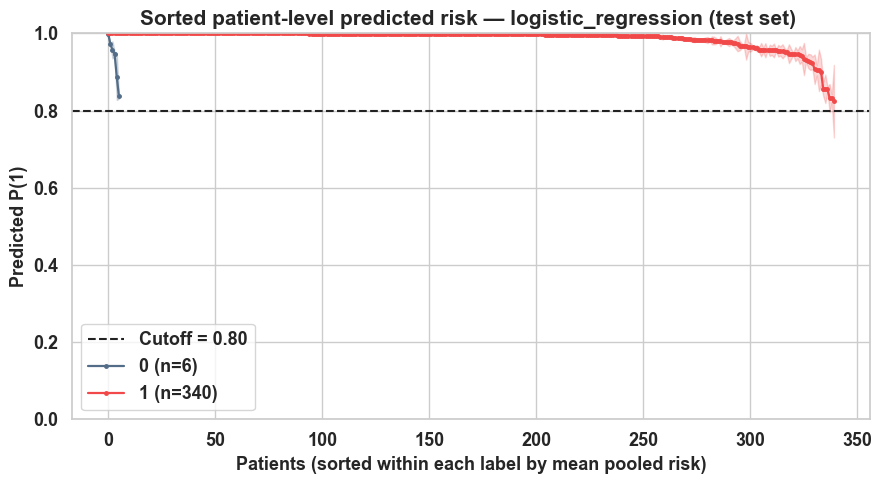

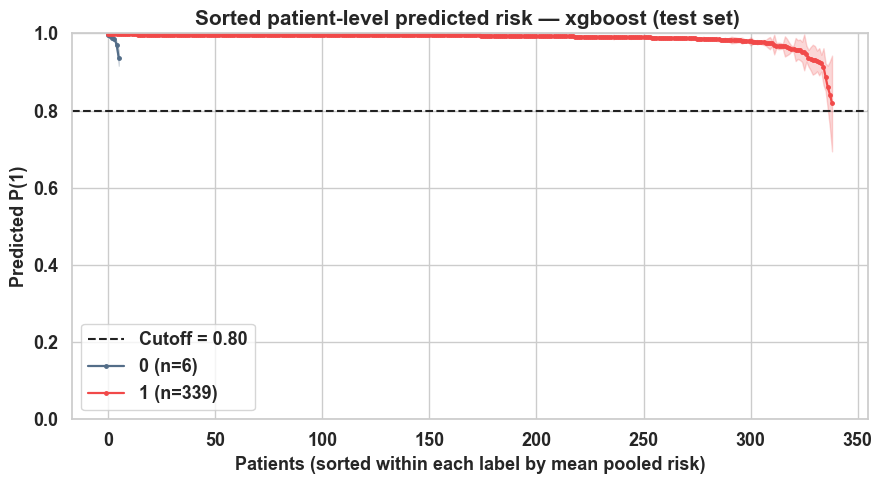

,0,1
model,logistic_regression,xgboost
variant,beta,beta
split,test,test
score_col,p_mean,p_mean
thr_low,0.8,0.8
thr_high,1.0,1.0
n_total,569,569
n_pos_total,357,357
n_neg_total,212,212
n_selected,346,345


In [18]:
_ = mtci.plot_ranked_patients_patient_level(
    df_hi_lr,
    model=None,
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],  
    split="test",
    group_label=None,              
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)


_ = mtci.plot_ranked_patients_patient_level(
    df_hi_xgb,
    model=None,
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],  
    split="test",
    group_label=None,               
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(8, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='index', # or 'index', 'percentile'
)



planning_table = pd.concat(
    [v["planning_summary"] for v in out.values()],
    axis=0,
    ignore_index=True,
)

display(planning_table.T)




### Chapter 2. Prospective enrichment workflow

This chapter demonstrates how the fixed enrichment rule is applied prospectively to patient-level data.

Given a set of screened patients, the ensemble model generates a patient-level predicted probability for each patient. The enrichment threshold is then applied to determine which patients are selected for the enriched cohort and which patients are not selected.

In [19]:

# Features used for model development: Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]


feature_filters = {
    "logistic_regression": lr_top,
    "xgboost": xgb_top
}

model_data_dict = post.synthetic_data_validation(
    final_features=final_features,
    feature_filters=feature_filters,
    make_semisynthetic=True,
    semisynthetic_n_per_class=10,
    semisynthetic_noise_scale=0.05,  # 5% of each feature's SD
    semisynthetic_clip_to_observed_range=True,
    semisynthetic_random_state=42,
)


### **Ensemble scoring** and enrichment decision
For each example patient, repeated model predictions are aggregated to obtain a patient-level ensemble probability.

Patients with predicted probability above the fixed threshold are selected for enrichment, while patients below the threshold are not selected.

In [20]:
# Synthetic data prep.
cols_lg = lr_top + ['y']
cols_xgb =   xgb_top + ['y']

test_data = {}
test_data['logistic_regression'] = model_data_dict['logistic_regression']['df_semisynthetic'][cols_lg]
test_data['xgboost']             = model_data_dict['xgboost']['df_semisynthetic'][cols_xgb]


# Generate external-set predictions for every fold model in `all_results` and store them back into each fold record using `*_external_*` keys (metrics only if labels exist).
#all_results    = mtci.load_all_results(output_dir='abcct_dataset_outputs/run_1/nonlinear_features', prefix='final_result', compress=True)
#all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)

all_results = vld.add_external_predictions_to_results(
    all_results,
    model_data_dict=test_data,
    y_col=None,   # or None if unlabeled, or just add the label column if present
    external_tag="external",
    feature_names_key="feature_names_used",
    strict_features=True,
)


# Build a single long-form  predictions table with one row per predicted example that is pooled across models. 
df_long = vld.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    include_uncalibrated=False,
)

# Aggregate repeated predictions per idx into a single row per (model, variant, idx), and optionally add an "ensemble" model by pooling predictions across multiple models.
df_agg = vld.aggregate_predictions_by_idx(
    df_long,
    calibrations=["uncalib", "beta"],
    add_ensemble=True,
    ensemble_name="Ensemble model",
    ensemble_models=None, #["logistic_regression", "xgboost"],  # optional; otherwise pools all selected
    truncate_decimals=4,
)

df_agg.head()

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used
0,Ensemble model,beta,0,NaN,30,0.0000,0.0000,0.0000,0.0000,0.0000,external,NaN,NaN
1,Ensemble model,beta,1,NaN,30,0.9958,0.9969,0.0042,0.9885,0.9999,external,NaN,NaN
2,Ensemble model,beta,2,NaN,30,0.9977,0.9983,0.0023,0.9924,0.9999,external,NaN,NaN
3,Ensemble model,beta,3,NaN,30,0.0000,0.0000,0.0000,0.0000,0.0000,external,NaN,NaN
4,Ensemble model,beta,4,NaN,30,0.0048,0.0018,0.0064,0.0000,0.0274,external,NaN,NaN


### Plot ranked screening predictions for enrichment decision-making.

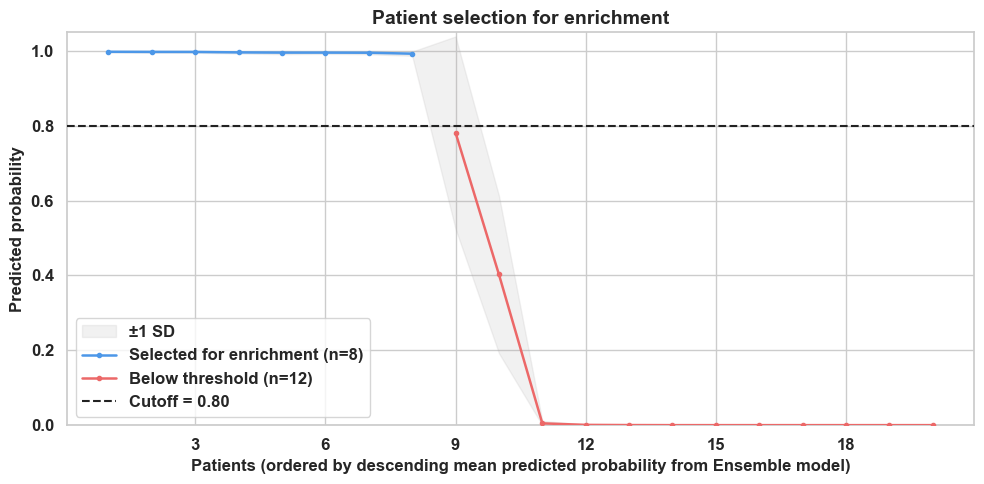

In [21]:
# In this example, we plot only the Ensemble model, so the function will:
#   1. order patients by the Ensemble model's p_mean values,
#   2. color patients above the cutoff as "selected for enrichment",
#   3. color patients at/below the cutoff as "below threshold",
#   4. show a neutral uncertainty ribbon using p_std.
ranked_dict = vld.plot_screening_predictions(
    df_pred=df_agg,                      # aggregated patient-level prediction table
    models=["Ensemble model"],           # models to plot; here we only show the Ensemble model
    # models=["logistic_regression", "xgboost", "Ensemble model"],  # example multi-model call

    reference_order_model="Ensemble model",  # model used to define the shared patient order on the x-axis
    calibration="beta",                 # use beta-calibrated probabilities
    center_col="p_mean",                # patient-level summary score used for ranking and thresholding
    std_col="p_std",                    # patient-level uncertainty column used for the ±1 SD ribbon

    figsize=(10, 5),                    # figure width and height
    cutoff=threshold,                        # fixed enrichment threshold: patients above this are considered selected
    ylim=(0, 1.05),                     # y-axis range; slight padding above 1.0 improves readability

    method_alias={                      # nicer display names used only in the plot labels
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
        "Ensemble model": "Ensemble model",
    },

    ribbon_color_single_model="#ADAAAA",  # neutral ribbon color for the single-model case
    title_prefix="Patient selection for enrichment",  # plot title
)


In [22]:
ranked_dict['Ensemble model'].head(3)

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used,patient_rank,selected_for_enrichment
0,Ensemble model,beta,15,NaN,30,0.9980,0.9983,0.0020,0.9926,0.9999,external,NaN,NaN,1,True
1,Ensemble model,beta,2,NaN,30,0.9977,0.9983,0.0023,0.9924,0.9999,external,NaN,NaN,2,True
2,Ensemble model,beta,17,NaN,30,0.9976,0.9980,0.0022,0.9924,0.9999,external,NaN,NaN,3,True
